<a href="https://colab.research.google.com/github/Balram524/GPS_mobility/blob/mains/Mobility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from geopy.distance import great_circle
import os

# 1. Data Preprocessing

def load_data(folder_path):
    """Load GPS data from all CSV files in the provided folder and assign device IDs."""
    data_frames = []

    for idx, file in enumerate(sorted(os.listdir(folder_path)), start=1):  # Sort files for consistent order
        if file.endswith('.csv'):
            print(f"Loading file: {file} as device_id {idx}")
            df = pd.read_csv(os.path.join(folder_path, file))
            df['device_id'] = idx  # Assign unique device_id
            data_frames.append(df)

    return pd.concat(data_frames, ignore_index=True)

# Use raw string for Windows path
folder_path = r"/content/sample_data/gps raw data"

# Load the data
gps_data = load_data(folder_path)

# Convert 'date_time' to datetime format
gps_data['date_time'] = pd.to_datetime(gps_data['date_time'])

Loading file: 19ff90fb-3207-4131-8d81-0b4ae01fd51d.csv as device_id 1
Loading file: 37aa5dbc-f531-40a3-9f63-aa534baf9753.csv as device_id 2
Loading file: 3e13999a-ed99-2a70-c448-dc297449fdd2.csv as device_id 3
Loading file: 4a8a69fd-63a0-4f6d-bd6b-df5ab35fdd67.csv as device_id 4
Loading file: 8e024a10-6edd-3edf-be1f-c44fbb6d3b8e.csv as device_id 5
Loading file: a7fc5498-3ef5-23bf-cc39-c9d2210213b9.csv as device_id 6
Loading file: ae9b4389-00df-40e1-aed6-035f85d180be.csv as device_id 7
Loading file: d61acf9b-f4b5-4627-9c89-698ae7d0b463.csv as device_id 8
Loading file: d9a69939-3382-4865-892b-210182ca6553.csv as device_id 9
Loading file: f977edb5-c406-4120-b508-37e167b981d6.csv as device_id 10
Loading file: fb0494d4-fe21-4fb3-8a91-5af88e14f244.csv as device_id 11


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
gps_data.head()

,date_time,latitude,longitude,accuracy,geohash,geohash_9,device_id
0,2023-07-09 06:24:18,28.630590,77.029114,9.0,ttnfbu4ck2g3,ttnfbu4ck,1
1,2023-07-09 06:24:46,28.630520,77.029152,10.0,ttnfbu4bv7c0,ttnfbu4bv,1
2,2023-07-09 06:24:47,28.630569,77.029182,12.0,ttnfbu4cjvpd,ttnfbu4cj,1
3,2023-07-09 06:25:50,28.630369,77.029167,20.0,ttnfbgfzvzb1,ttnfbgfzv,1
4,2023-07-09 06:25:51,28.630541,77.029160,14.0,ttnfbu4bvx2x,ttnfbu4bv,1


In [18]:

# Define the correct path
output_dir = r"D:\Desktop\gps_data"  # Use raw string (r"") to avoid escape sequence issues
output_file = os.path.join(output_dir, "gps_data_combined.csv")

# Create the directory if it does not exist
os.makedirs(output_dir, exist_ok=True)

# Save the DataFrame to CSV
gps_data.to_csv(output_file, index=False)

print(f"File saved successfully at: {output_file}")


File saved successfully at: D:\Desktop\gps_data/gps_data_combined.csv


1. Data preprocessing

In [19]:

# Create DataFrame
df = pd.DataFrame(gps_data)

# Convert to datetime format
df["datetime"] = pd.to_datetime(df["date_time"])

# Create separate columns for date and time
df["date"] = df["date_time"].dt.date
df["time"] = df["date_time"].dt.time

# Drop the original date_time column if needed
df.drop(columns=["date_time"], inplace=True)
df.head()


,latitude,longitude,accuracy,geohash,geohash_9,device_id,datetime,date,time
0,28.630590,77.029114,9.0,ttnfbu4ck2g3,ttnfbu4ck,1,2023-07-09 06:24:18,2023-07-09,06:24:18
1,28.630520,77.029152,10.0,ttnfbu4bv7c0,ttnfbu4bv,1,2023-07-09 06:24:46,2023-07-09,06:24:46
2,28.630569,77.029182,12.0,ttnfbu4cjvpd,ttnfbu4cj,1,2023-07-09 06:24:47,2023-07-09,06:24:47
3,28.630369,77.029167,20.0,ttnfbgfzvzb1,ttnfbgfzv,1,2023-07-09 06:25:50,2023-07-09,06:25:50
4,28.630541,77.029160,14.0,ttnfbu4bvx2x,ttnfbu4bv,1,2023-07-09 06:25:51,2023-07-09,06:25:51


In [20]:
df.shape

(403557, 9)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403557 entries, 0 to 403556
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   latitude   403557 non-null  float64       
 1   longitude  403557 non-null  float64       
 2   accuracy   403557 non-null  float64       
 3   geohash    403557 non-null  object        
 4   geohash_9  403557 non-null  object        
 5   device_id  403557 non-null  int64         
 6   datetime   403557 non-null  datetime64[ns]
 7   date       403557 non-null  object        
 8   time       403557 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 27.7+ MB


In [22]:
df.count()


,0
latitude,403557
longitude,403557
accuracy,403557
geohash,403557
geohash_9,403557
device_id,403557
datetime,403557
date,403557
time,403557


In [23]:
df.isna().sum()
df.isnull().sum()


,0
latitude,0
longitude,0
accuracy,0
geohash,0
geohash_9,0
device_id,0
datetime,0
date,0
time,0



2. Data analyzation and Visualization


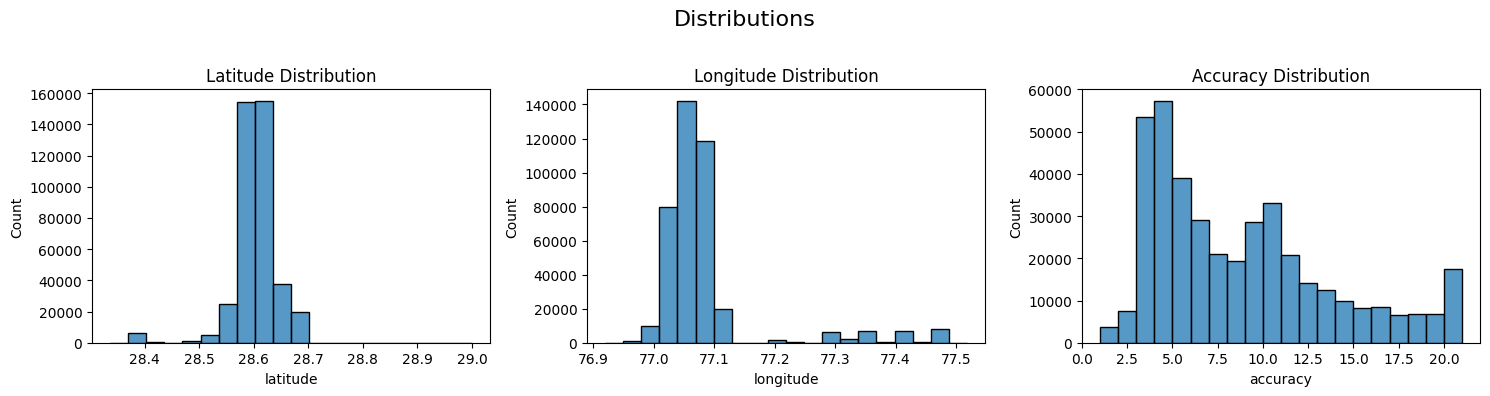

In [24]:
# 1. Distributions
plt.figure(figsize=(15, 4))
plt.suptitle("Distributions", fontsize=16)

plt.subplot(1, 3, 1)
sns.histplot(df['latitude'], bins=20)
plt.title("Latitude Distribution")

plt.subplot(1, 3, 2)
sns.histplot(df['longitude'], bins=20)
plt.title("Longitude Distribution")

plt.subplot(1, 3, 3)
sns.histplot(df['accuracy'], bins=20)
plt.title("Accuracy Distribution")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



In [ ]:
# 2. Categorical Distributions
plt.figure(figsize=(12, 6))
plt.suptitle("Categorical Distributions", fontsize=16)

plt.subplot(1, 2, 1)
sns.countplot(y=df['geohash_9'], palette='viridis')
plt.title("Geohash 9 Distribution")

plt.subplot(1, 2, 2)
sns.countplot(y=df['geohash'], palette='coolwarm')
plt.title("Geohash Distribution")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# 3. 2D Distributions
plt.figure(figsize=(12, 6))
plt.suptitle("2D Distributions", fontsize=16)

plt.subplot(1, 2, 1)
sns.scatterplot(x=df['longitude'], y=df['latitude'])
plt.title("Latitude vs Longitude")

plt.subplot(1, 2, 2)
sns.scatterplot(x=df['latitude'], y=df['accuracy'])
plt.title("Latitude vs Accuracy")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# 4. Time Series
plt.figure(figsize=(15, 6))
plt.suptitle("Time Series", fontsize=16)

plt.subplot(1, 3, 1)
sns.lineplot(x=df['datetime'], y=df['latitude'])
plt.title("Latitude Over Time")

plt.subplot(1, 3, 2)
sns.lineplot(x=df['datetime'], y=df['longitude'])
plt.title("Longitude Over Time")

plt.subplot(1, 3, 3)
sns.lineplot(x=df['datetime'], y=df['accuracy'])
plt.title("Accuracy Over Time")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [27]:
df.head()

,latitude,longitude,accuracy,geohash,geohash_9,device_id,datetime,date,time
0,28.630590,77.029114,9.0,ttnfbu4ck2g3,ttnfbu4ck,1,2023-07-09 06:24:18,2023-07-09,06:24:18
1,28.630520,77.029152,10.0,ttnfbu4bv7c0,ttnfbu4bv,1,2023-07-09 06:24:46,2023-07-09,06:24:46
2,28.630569,77.029182,12.0,ttnfbu4cjvpd,ttnfbu4cj,1,2023-07-09 06:24:47,2023-07-09,06:24:47
3,28.630369,77.029167,20.0,ttnfbgfzvzb1,ttnfbgfzv,1,2023-07-09 06:25:50,2023-07-09,06:25:50
4,28.630541,77.029160,14.0,ttnfbu4bvx2x,ttnfbu4bv,1,2023-07-09 06:25:51,2023-07-09,06:25:51


from matplotlib import pyplot as plt
_df_48['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_49['latitude'].plot(kind='hist', bins=20, title='latitude')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_50['longitude'].plot(kind='hist', bins=20, title='longitude')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_51['accuracy'].plot(kind='hist', bins=20, title='accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_69['geohash_9'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_69, x='index', y='geohash_9', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_70['time'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_70, x='index', y='time', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_71['geohash'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_71, x='latitude', y='geohash', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
# 5 Distribution of GPS Points Per Geohash
plt.figure(figsize=(12, 6))
sns.countplot(y=df["geohash_9"], order=df["geohash_9"].value_counts().index)
plt.xlabel("Number of GPS Points")
plt.ylabel("Geohash 9")
plt.title("GPS Data Distribution per Geohash 9")
plt.show()

# Time-Based Analysis (Hourly Distribution)
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour
plt.figure(figsize=(10, 5))
sns.histplot(df['hour'], bins=24, kde=True)
plt.xlabel("Hour of the Day")
plt.ylabel("Number of GPS Records")
plt.title("Hourly GPS Data Distribution")
plt.show()


Analyze the trip of each device and find maximum distance travelled and Time duration.


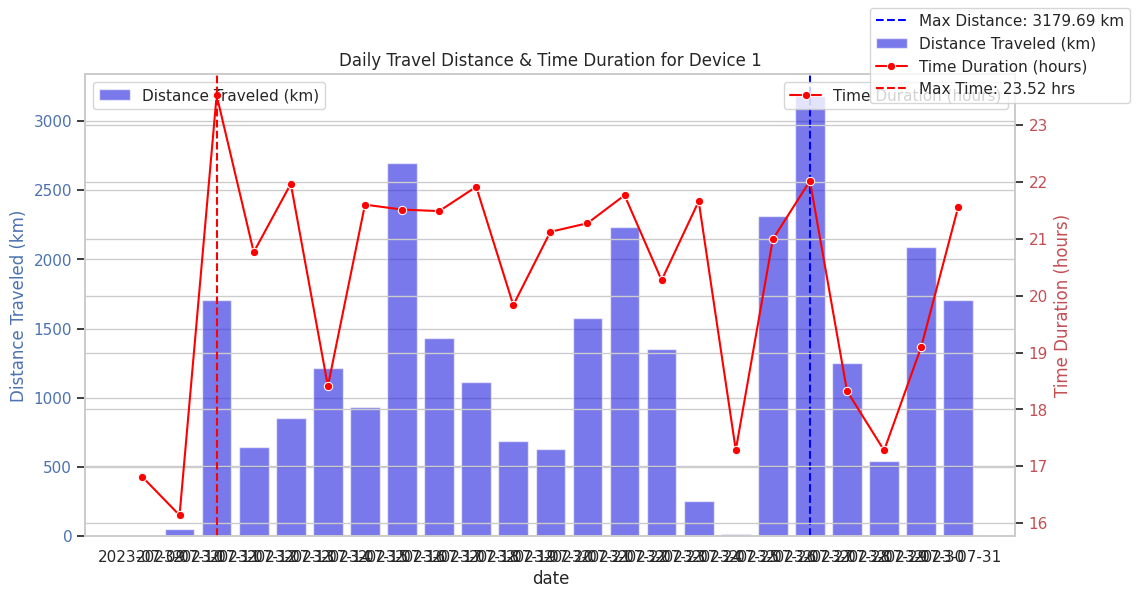

Device 1:
- Max Travel Date: 2023-07-27, Distance: 3179.69 km
- Max Time Date: 2023-07-11, Duration: 23.52 hours



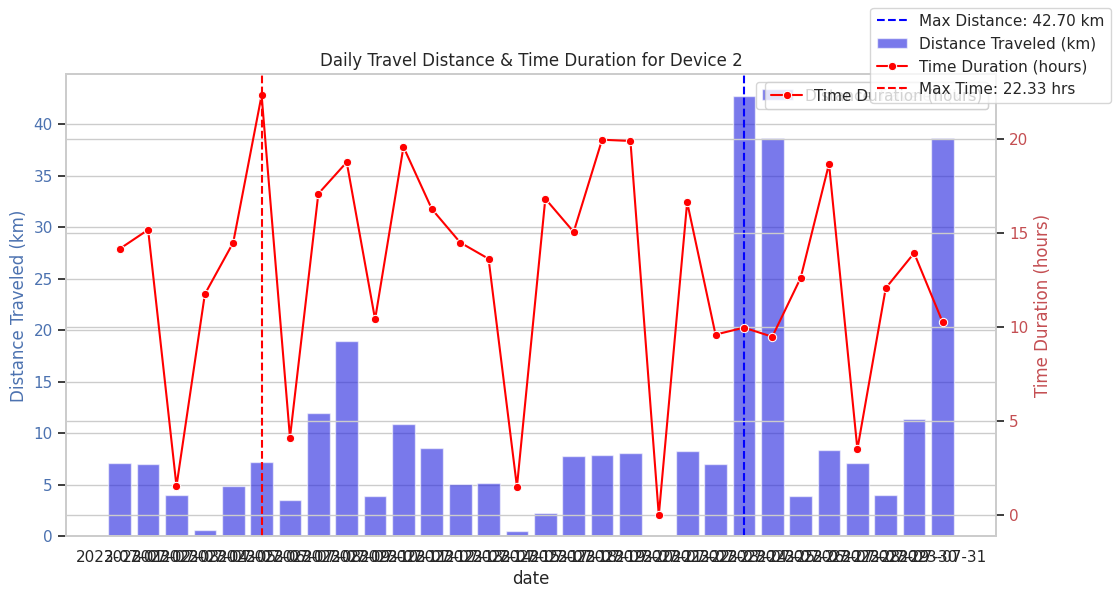

Device 2:
- Max Travel Date: 2023-07-24, Distance: 42.70 km
- Max Time Date: 2023-07-06, Duration: 22.33 hours



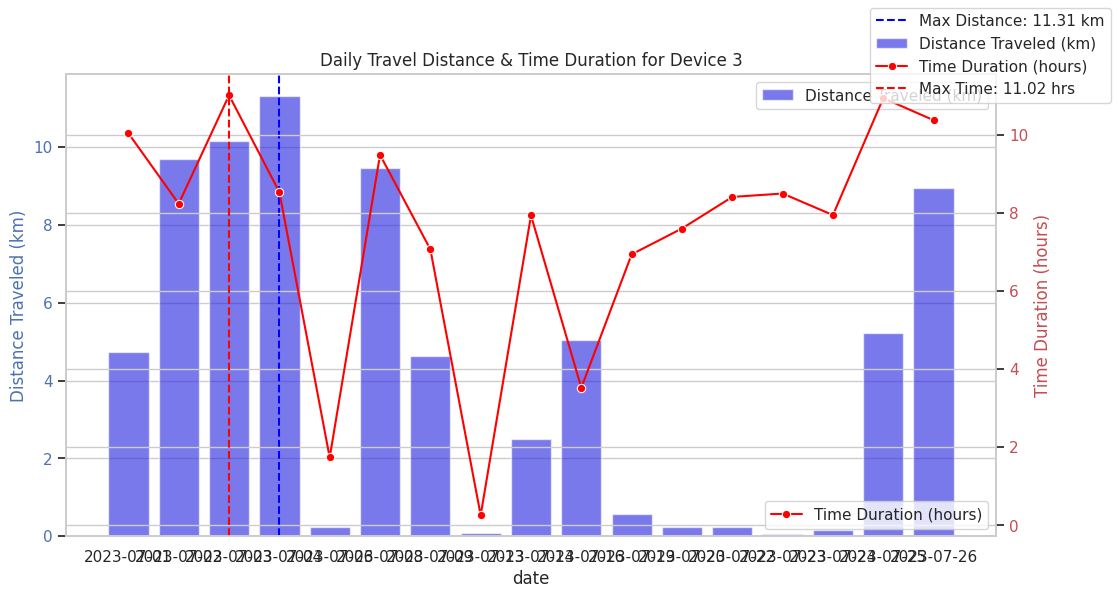

Device 3:
- Max Travel Date: 2023-07-04, Distance: 11.31 km
- Max Time Date: 2023-07-03, Duration: 11.02 hours



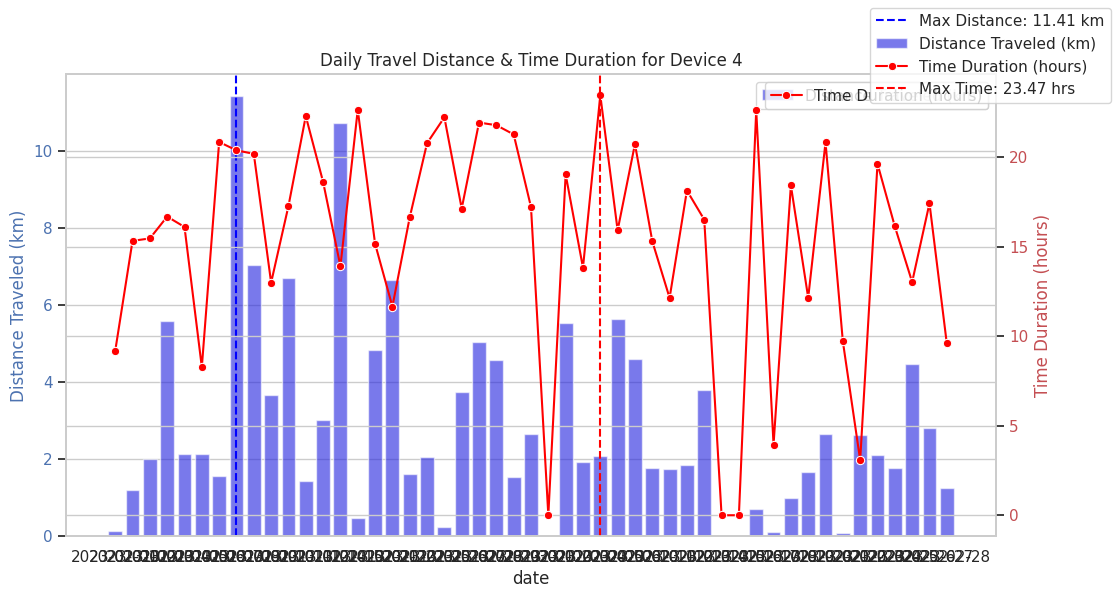

Device 4:
- Max Travel Date: 2023-01-08, Distance: 11.41 km
- Max Time Date: 2023-02-05, Duration: 23.47 hours



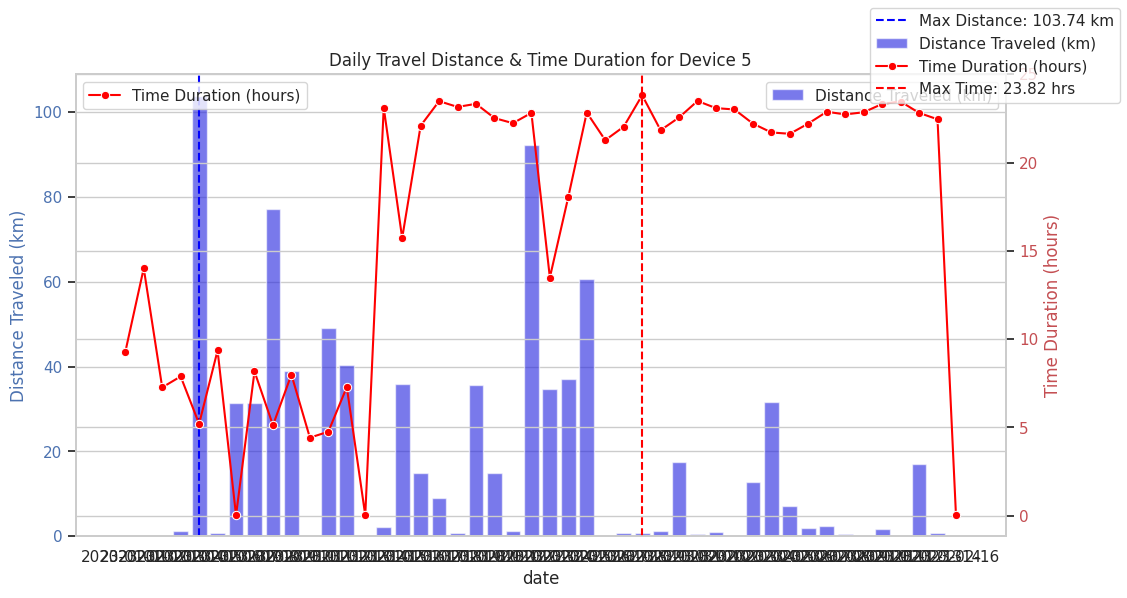

Device 5:
- Max Travel Date: 2023-01-05, Distance: 103.74 km
- Max Time Date: 2023-01-29, Duration: 23.82 hours



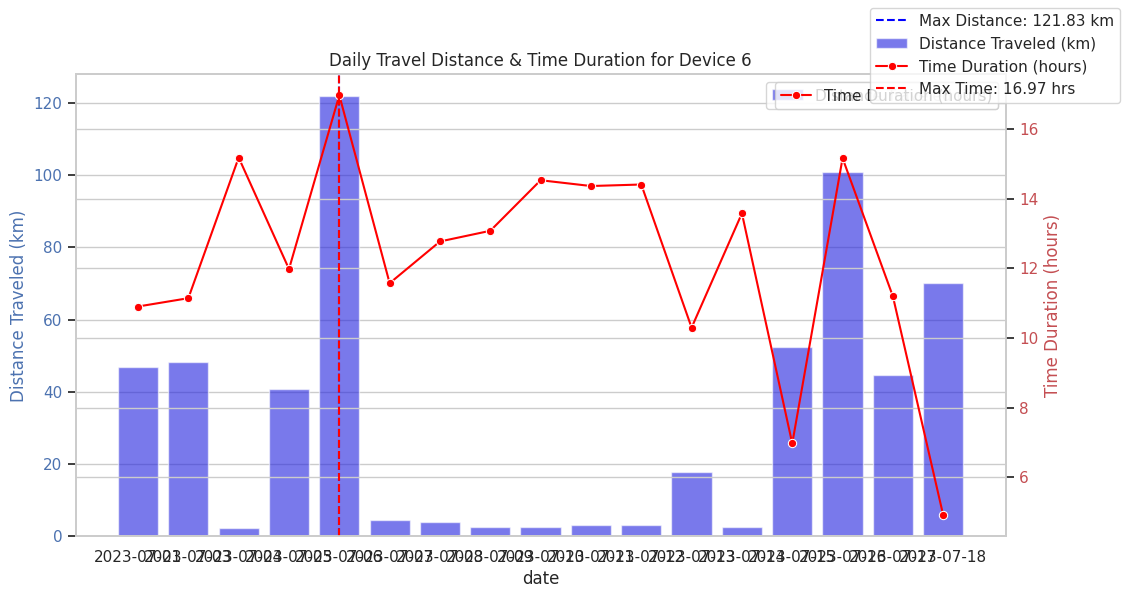

Device 6:
- Max Travel Date: 2023-07-06, Distance: 121.83 km
- Max Time Date: 2023-07-06, Duration: 16.97 hours



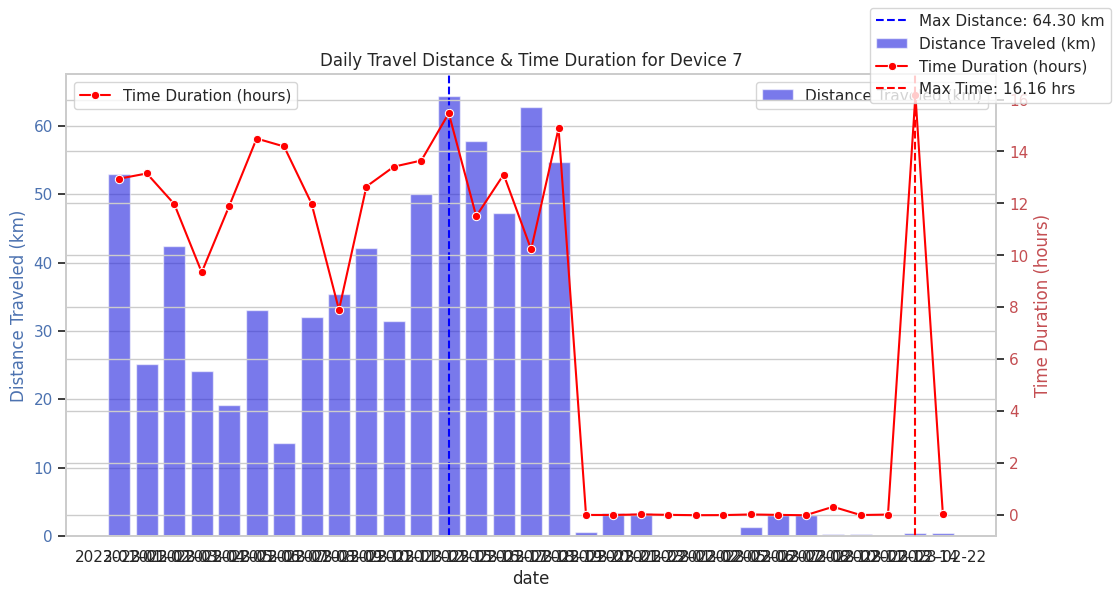

Device 7:
- Max Travel Date: 2023-01-15, Distance: 64.30 km
- Max Time Date: 2023-02-14, Duration: 16.16 hours



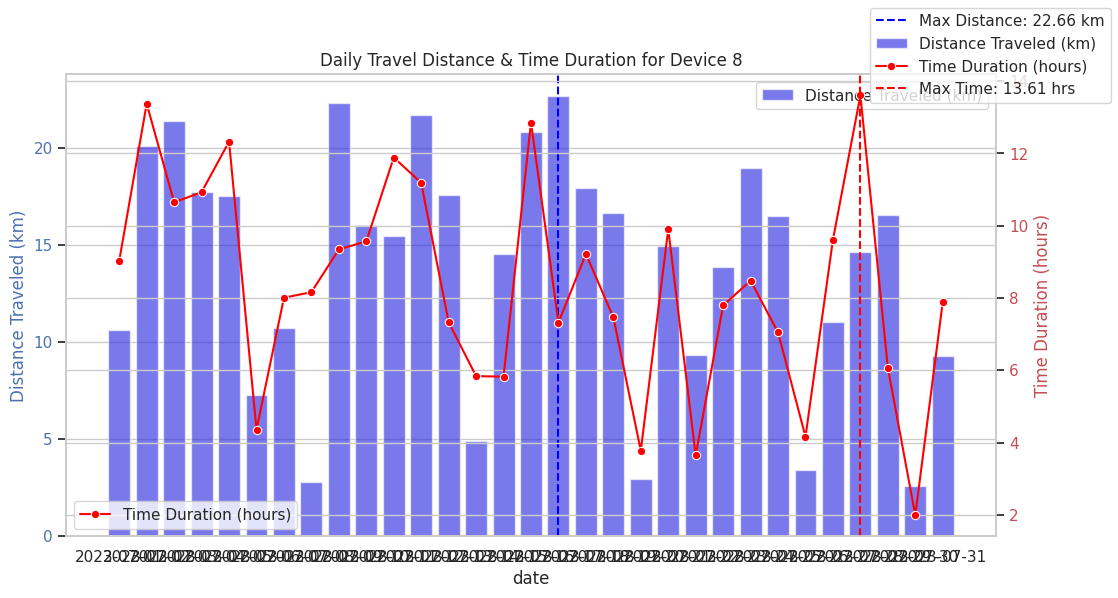

Device 8:
- Max Travel Date: 2023-07-17, Distance: 22.66 km
- Max Time Date: 2023-07-28, Duration: 13.61 hours



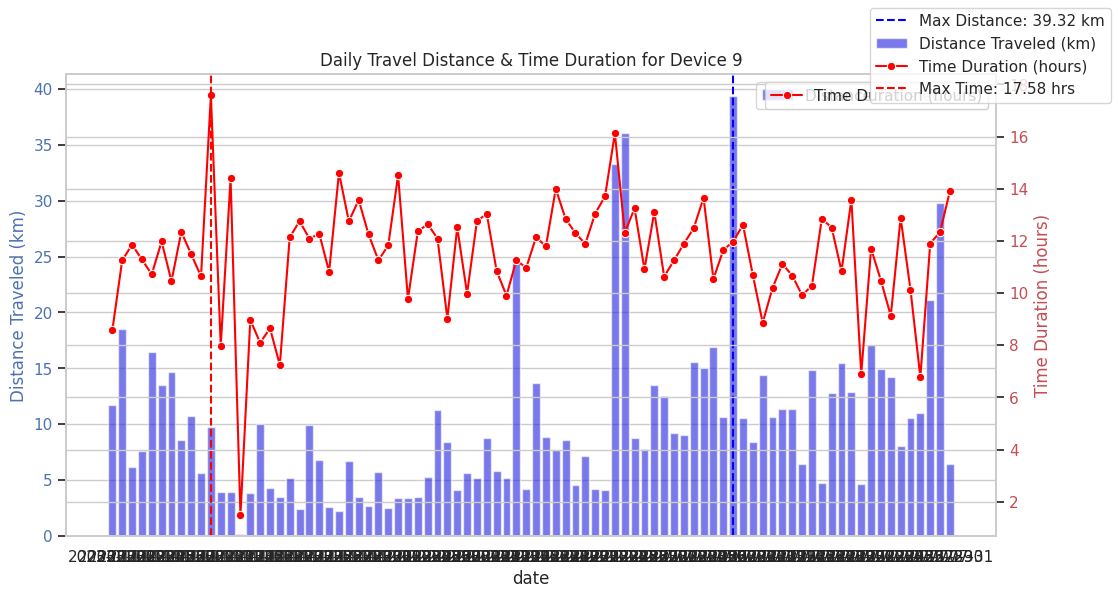

Device 9:
- Max Travel Date: 2023-07-09, Distance: 39.32 km
- Max Time Date: 2023-01-11, Duration: 17.58 hours



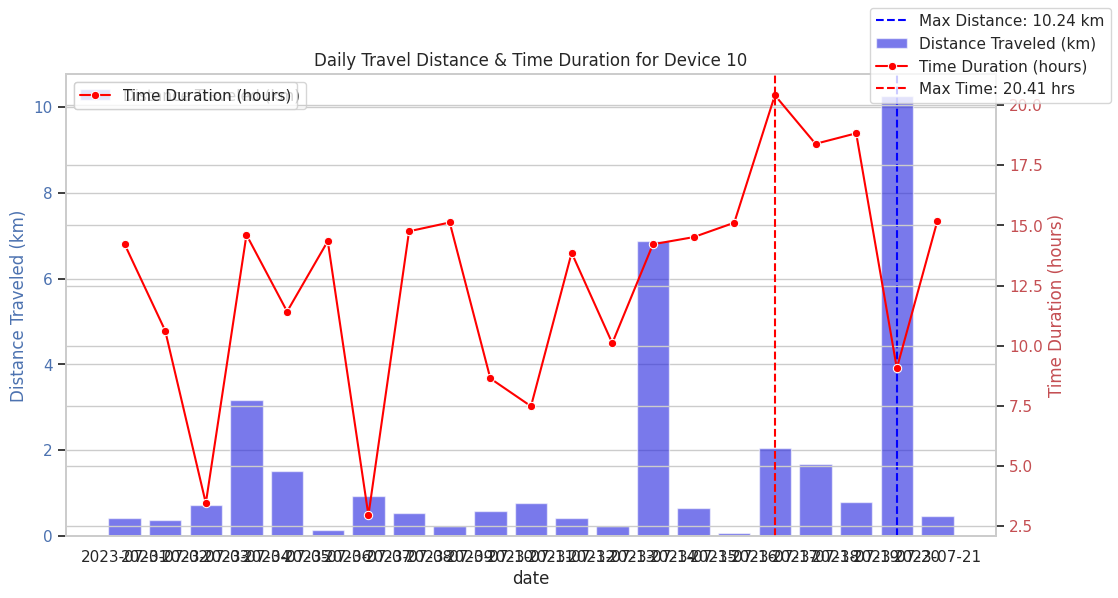

Device 10:
- Max Travel Date: 2023-07-20, Distance: 10.24 km
- Max Time Date: 2023-07-17, Duration: 20.41 hours



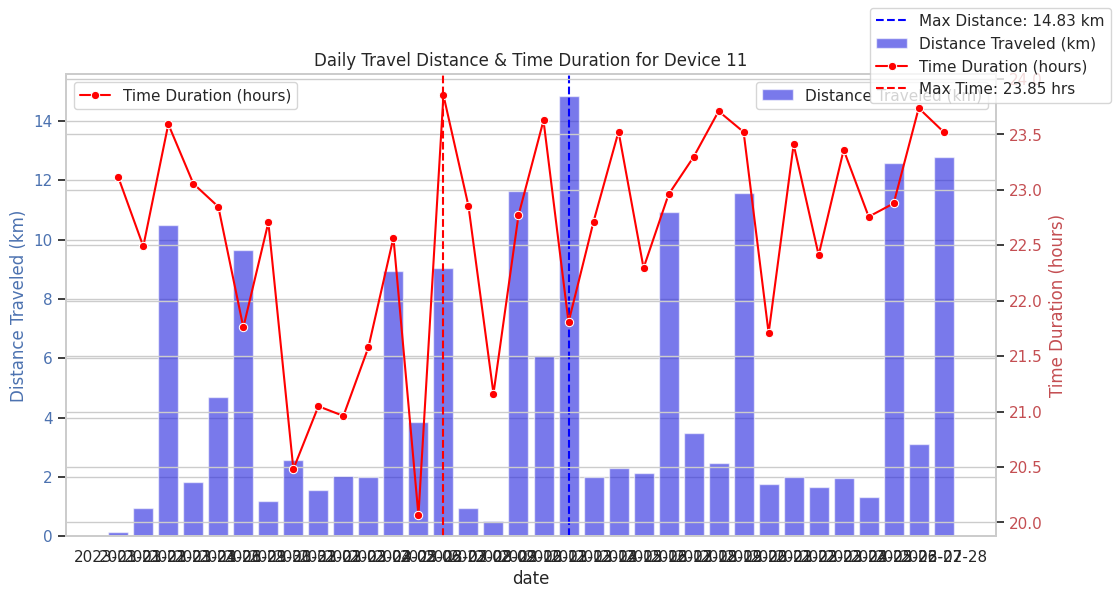

Device 11:
- Max Travel Date: 2023-02-13, Distance: 14.83 km
- Max Time Date: 2023-02-07, Duration: 23.85 hours



In [ ]:
# Function to calculate Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c  # Distance in km

# Shift lat/lon per device to get previous locations
df['prev_lat'] = df.groupby('device_id')['latitude'].shift(1)
df['prev_lon'] = df.groupby('device_id')['longitude'].shift(1)

# Compute distance using Haversine formula
df['distance_km'] = df.apply(lambda row: haversine(row['prev_lat'], row['prev_lon'], row['latitude'], row['longitude']), axis=1)
df['distance_km'] = df['distance_km'].fillna(0)

# Compute daily statistics: total travel distance and time duration
time_duration = df.groupby(['device_id', 'date']).agg(
    start_time=('datetime', 'min'),
    end_time=('datetime', 'max'),
    total_distance=('distance_km', 'sum')
).reset_index()

time_duration['duration_hours'] = (time_duration['end_time'] - time_duration['start_time']).dt.total_seconds() / 3600  # Convert to hours

# Find max travel distance and max time duration for each device
for device in df['device_id'].unique():
    device_data = time_duration[time_duration['device_id'] == device]

    max_distance_entry = device_data.loc[device_data['total_distance'].idxmax()]
    max_time_entry = device_data.loc[device_data['duration_hours'].idxmax()]

    max_travel_date = str(max_distance_entry['date'])  # Convert to string
    max_travel_value = max_distance_entry['total_distance']

    max_time_date = str(max_time_entry['date'])  # Convert to string
    max_time_value = max_time_entry['duration_hours']

    # Plot bar graph for distance and line plot for time duration
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Bar Plot for Travel Distance
    sns.barplot(x=device_data['date'].astype(str), y=device_data['total_distance'], ax=ax1, color='blue', alpha=0.6, label="Distance Traveled (km)")
    ax1.set_ylabel("Distance Traveled (km)", color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    # Line Plot for Time Duration
    ax2 = ax1.twinx()
    sns.lineplot(x=device_data['date'].astype(str), y=device_data['duration_hours'], ax=ax2, color='red', marker='o', label="Time Duration (hours)")
    ax2.set_ylabel("Time Duration (hours)", color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    plt.title(f"Daily Travel Distance & Time Duration for Device {device}")
    plt.xticks(rotation=45)

    # Highlight max travel and max time with vertical lines
    ax1.axvline(x=max_travel_date, color="blue", linestyle="--", label=f"Max Distance: {max_travel_value:.2f} km")
    ax2.axvline(x=max_time_date, color="red", linestyle="--", label=f"Max Time: {max_time_value:.2f} hrs")

    fig.legend(loc="upper right")
    plt.show()

    # Print maximum travel and time details
    print(f"Device {device}:")
    print(f"- Max Travel Date: {max_travel_date}, Distance: {max_travel_value:.2f} km")
    print(f"- Max Time Date: {max_time_date}, Duration: {max_time_value:.2f} hours\n")


3. Trip and Dwell detection

In [ ]:
!pip install haversine

from haversine import haversine

def detect_trips_and_dwells(data, distance_threshold=0.2, time_threshold=pd.Timedelta('5 minutes')):
    """
    Detect trips and dwells based on distance and time thresholds.
    """
    trips = []
    dwells = []

    # Ensure data is sorted by timestamp
    data = data.sort_values(by='datetime').reset_index(drop=True)

    current_trip = []
    current_dwell = []

    for i in range(1, len(data)):
        prev_point = (data.iloc[i-1]['latitude'], data.iloc[i-1]['longitude'])
        curr_point = (data.iloc[i]['latitude'], data.iloc[i]['longitude'])

        #  Compute Haversine Distance (instead of `great_circle`)
        distance = haversine(prev_point, curr_point)  # Distance in km
        time_diff = data.iloc[i]['datetime'] - data.iloc[i-1]['datetime']

        #  If moved significantly → Trip
        if distance > distance_threshold:
            if current_dwell:
                dwells.append(current_dwell)
                current_dwell = []
            current_trip.append(data.iloc[i])

        #  If stayed but long enough → Dwell
        elif time_diff > time_threshold:
            if current_trip:
                trips.append(current_trip)
                current_trip = []
            current_dwell.append(data.iloc[i])

    #  Save any remaining trip or dwell
    if current_trip:
        trips.append(current_trip)
    if current_dwell:
        dwells.append(current_dwell)

    return trips, dwells

# Run function on `df`
trips, dwells = detect_trips_and_dwells(df)

print(f"Detected {len(trips)} trips and {len(dwells)} dwells.")


Detected 1225 trips and 1225 dwells.


In [ ]:
print(trips[:2])  # View first 2 trips
print(dwells[:2]) # View first 2 dwells


[[latitude                28.51174
longitude              77.427628
accuracy                    14.0
geohash             ttp41ymhfmqf
geohash_9              ttp41ymhf
device_id                      4
datetime     2023-01-01 03:50:18
date                  2023-01-01
time                    03:50:18
Name: 14, dtype: object, latitude                28.55197
longitude               77.34935
accuracy                     4.0
geohash             ttp42jsp62zx
geohash_9              ttp42jsp6
device_id                      7
datetime     2023-01-01 04:15:06
date                  2023-01-01
time                    04:15:06
Name: 15, dtype: object, latitude                28.51174
longitude              77.427628
accuracy                    14.0
geohash             ttp41ymhfmqf
geohash_9              ttp41ymhf
device_id                      4
datetime     2023-01-01 04:23:19
date                  2023-01-01
time                    04:23:19
Name: 33, dtype: object], [latitude               28.3776

In [ ]:
import folium
import random
from folium.plugins import MarkerCluster
from haversine import haversine

def generate_color():
    """Generate a random HEX color."""
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

def plot_trips_and_dwells(data, trips, dwells):

    # Initialize the map at the dataset's mean location
    m = folium.Map(location=[data['latitude'].mean(), data['longitude'].mean()], zoom_start=12)

    # Plot Trips (Each with Unique Color)
    for trip in trips:
        trip_color = generate_color()  # Assign unique color
        coords = [(row['latitude'], row['longitude']) for row in trip]

        # Draw trip path
        folium.PolyLine(coords, color=trip_color, weight=4, opacity=0.8).add_to(m)

        # Mark trip points with accuracy circles and tooltips
        for row in trip:
            folium.Circle(
                location=[row['latitude'], row['longitude']],
                radius=row['accuracy'] * 2,  # Accuracy scaled
                color=trip_color,
                fill=True,
                fill_color=trip_color,
                fill_opacity=0.4,
                popup=f"Device: {row['device_id']}<br>DateTime: {row['datetime']}<br>Accuracy: {row['accuracy']}m",
                tooltip="Trip Point"
            ).add_to(m)

    # Plot Dwells (Clustered Red Markers)
    dwell_cluster = MarkerCluster().add_to(m)
    for dwell in dwells:
        lat = dwell[0]['latitude']
        lon = dwell[0]['longitude']

        folium.CircleMarker(
            location=[lat, lon],
            radius=6,
            color='red',
            fill=True,
            fill_color='red',
            fill_opacity=0.9,
            popup=f"Dwell Location<br>Lat: {lat}<br>Lon: {lon}",
            tooltip="Dwell Point"
        ).add_to(dwell_cluster)

    return m

#  Generate interactive map
trip_dwell_map = plot_trips_and_dwells(df, trips, dwells)

#  Save and display
trip_dwell_map.save('enhanced_trips_and_dwells_map.html')
trip_dwell_map


Buffered data was truncated after reaching the output size limit.

Analysis of timestamp and web page for better interaction.

In [ ]:
# Convert 'datetime' to datetime format
df['datetime'] = pd.to_datetime(df['datetime'])

def plot_enhanced_gps_data(data):

    # Adaptive sampling based on dataset size
    sample_rate = max(1, len(data) // 500)  # Keeps ~500 points max for performance
    sampled_data = data.iloc[::sample_rate]

    # Initialize map centered on the dataset
    m = folium.Map(
        location=[data['latitude'].mean(), data['longitude'].mean()],
        zoom_start=12,
        tiles="CartoDB Positron"
    )

    # Add Marker Cluster
    marker_cluster = MarkerCluster().add_to(m)

    # Add markers with tooltips
    for _, row in sampled_data.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=4,
            color='blue',
            fill=True,
            fill_opacity=0.7,
            popup=f"<b>Device:</b> {row['device_id']}<br><b>Time:</b> {row['datetime']}<br><b>Accuracy:</b> {row['accuracy']} m",
            tooltip=f"Time: {row['datetime']} | Accuracy: {row['accuracy']}m"
        ).add_to(marker_cluster)

    # Draw a simplified travel path with reduced opacity
    folium.PolyLine(
        list(zip(sampled_data['latitude'], sampled_data['longitude'])),
        color="red",
        weight=2,
        opacity=0.7,
        tooltip="Travel Path"
    ).add_to(m)

    return m

# Generate and save the interactive map
enhanced_map = plot_enhanced_gps_data(df)
enhanced_map.save('enhanced_gps_map.html')


 4. Overlay with Google Open Buildings Dataset


In [ ]:
!pip install geemap earthengine-api geopandas shapely
!pip install earthengine-api


In [28]:
# Import Libraries
import ee
import geemap

# Authenticate and initialize GEE
ee.Authenticate()
ee.Initialize(project="my-gps-project-454717")  # Use your new project ID

print(" Google Earth Engine Initialized!")


 Google Earth Engine Initialized!


In [29]:
# Define the Area of Interest (AOI) - Delhi, Noida, and Gurugram
aoi = ee.Geometry.Rectangle([76.7, 28.4, 77.5, 28.9])  # Approximate Bounding Box


In [30]:
# Load Open Buildings Dataset
buildings = ee.FeatureCollection("GOOGLE/Research/open-buildings/v3/polygons")

# Filter buildings within the AOI
buildings_aoi = buildings.filterBounds(aoi)

print("Buildings dataset loaded successfully!")


Buildings dataset loaded successfully!


In [7]:
# Export the dataset to Google Drive
task = ee.batch.Export.table.toDrive(
    collection=buildings_aoi,
    description="OpenBuildings_Delhi_Noida_Gurugram",
    fileFormat="GeoJSON"
)
task.start()

print(" Check Google Drive for 'OpenBuildings_Delhi_Noida_Gurugram.geojson'")


 Check Google Drive for 'OpenBuildings_Delhi_Noida_Gurugram.geojson'


In [ ]:
task.status()


Move the downloaded gps data from device to google colab and downloaded locally

In [9]:
import shutil

# Define the source and destination paths
source_path = "/content/drive/My Drive/OpenBuildings_Delhi_Noida_Gurugram.geojson"
dest_path = "/content/OpenBuildings_Delhi_Noida_Gurugram.geojson"

# Copy the file
shutil.copy(source_path, dest_path)

print(f"Dataset copied to Colab storage at: {dest_path}")


✅ Dataset copied to Colab storage at: /content/OpenBuildings_Delhi_Noida_Gurugram.geojson


In [ ]:
from google.colab import files

files.download("/content/OpenBuildings_Delhi_Noida_Gurugram.geojson")
print("File Downloaded to Your Local Storage!")


In [10]:
# Create an interactive map
map_ = geemap.Map()

# Add AOI and buildings
map_.addLayer(aoi, {"color": "red"}, "Area of Interest")
map_.addLayer(buildings_aoi, {"color": "blue"}, "Google Open Buildings")

# Display map
map_


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

Load the OpenBuildings Dataset into Python

In [ ]:
import geopandas as gpd

# Load the Open Buildings dataset
buildings = gpd.read_file("/content/drive/MyDrive/OpenBuildings_Delhi_Noida_Gurugram.geojson")

# Check the first few records
print(buildings.head())

# Check the coordinate reference system (CRS)
print(buildings.crs)


Load and Process GPS Data

In [ ]:
# Load GPS Data
gps_data = pd.read_csv("/content/sample_data/combined gps data/gps_data_combined (1).csv")  # Replace with your actual file name

# Convert GPS Data to GeoDataFrame
from shapely.geometry import Point

gps_data["geometry"] = gps_data.apply(lambda row: Point(row["longitude"], row["latitude"]), axis=1)
gps_gdf = gpd.GeoDataFrame(gps_data, geometry="geometry", crs="EPSG:4326")  # Ensure correct CRS

# Reproject to match OpenBuildings CRS
gps_gdf = gps_gdf.to_crs(buildings.crs)

# Check first few rows
print(gps_gdf.head())


# 5. Synthesize trips

In [ ]:
# 5. Synthesize trips
import geopandas as gpd

# Ensure CRS consistency before spatial operations
if gps_gdf.crs != buildings.crs:
    gps_gdf = gps_gdf.to_crs(buildings.crs)

# Perform a nearest spatial join to find the closest building for each GPS point
gps_with_buildings = gpd.sjoin_nearest(gps_gdf, buildings, how="left", distance_col="building_distance")

# Select relevant columns for output
gps_with_buildings = gps_with_buildings[
    ["date_time", "latitude", "longitude", "accuracy", "geohash", "geohash_9", "device_id",
     "id", "area_in_meters", "confidence", "full_plus_code", "building_distance"]
]

# Save the result as a CSV file
csv_output_path = "/content/gps_with_buildings.csv"  # Change the path if needed
gps_with_buildings.to_csv(csv_output_path, index=False)

# Print a sample to verify correctness
print(gps_with_buildings.head())





In [ ]:
# Ensure `date_time` is in datetime format
gps_gdf["date_time"] = pd.to_datetime(gps_gdf["date_time"])

# Convert both datasets to a projected CRS (for accurate distance calculations)
projected_crs = "EPSG:32643"  # UTM Zone 43N for India
gps_gdf = gps_gdf.to_crs(projected_crs)
buildings = buildings.to_crs(projected_crs)

# Sort by device_id & time for trip identification
gps_gdf = gps_gdf.sort_values(by=["device_id", "date_time"])

# Compute time difference between consecutive pings per device
gps_gdf["time_diff"] = gps_gdf.groupby("device_id")["date_time"].diff().dt.total_seconds().fillna(0)

# Identify trip start & end points
gps_gdf["trip_start"] = gps_gdf["time_diff"] > 300  # New trip if gap > 5 min
gps_gdf["trip_id"] = gps_gdf["trip_start"].cumsum()  # Unique trip IDs
gps_gdf["trip_end"] = gps_gdf["trip_id"] != gps_gdf["trip_id"].shift(-1)

# Link GPS data to nearest buildings
gps_with_buildings = gpd.sjoin_nearest(gps_gdf, buildings, how="left", distance_col="building_distance")

# Debugging Step: Check if 'id' exists
print("Columns after spatial join:", gps_with_buildings.columns)

# Compute dwell times (ensure 'id' exists)
if "id" in gps_with_buildings.columns:
    gps_with_buildings["dwell_time"] = gps_with_buildings.groupby(["device_id", "id"])["time_diff"].cumsum()
else:
    print("Warning: 'id' column is missing from the spatial join result!")

# Select relevant columns
output_data = gps_with_buildings[
    ["device_id", "date_time", "latitude", "longitude", "accuracy", "trip_id", "trip_start", "trip_end",
     "id", "area_in_meters", "confidence", "full_plus_code", "building_distance", "dwell_time"]
]

# Save to CSV
csv_output_path = "/content/gps_trips_with_buildings.csv"
output_data.to_csv(csv_output_path, index=False)

# Print sample output
print(output_data.head())


In [3]:
trip_analysis = pd.read_csv("/content/gps_with_buildings.csv")
trip_analysis.head()

,date_time,latitude,longitude,accuracy,geohash,geohash_9,device_id,id,area_in_meters,confidence,full_plus_code,building_distance
0,2023-07-09 06:24:18,28.630590,77.029114,9.0,ttnfbu4ck2g3,ttnfbu4ck,1,098800000000000b5926,145.937103,0.7798,7JWVJ2JH+6JXJ,0.000000
1,2023-07-09 06:24:46,28.630520,77.029152,10.0,ttnfbu4bv7c0,ttnfbu4bv,1,098800000000000b5926,145.937103,0.7798,7JWVJ2JH+6JXJ,0.000037
2,2023-07-09 06:24:47,28.630569,77.029182,12.0,ttnfbu4cjvpd,ttnfbu4cj,1,09880000000000086764,339.915710,0.7794,7JWVJ2JH+7P2H,0.000008
3,2023-07-09 06:25:50,28.630369,77.029167,20.0,ttnfbgfzvzb1,ttnfbgfzv,1,09880000000000134671,155.095398,0.7218,7JWVJ2JH+4PJF,0.000001
4,2023-07-09 06:25:51,28.630541,77.029160,14.0,ttnfbu4bvx2x,ttnfbu4bv,1,098800000000000b5926,145.937103,0.7798,7JWVJ2JH+6JXJ,0.000018


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['latitude'].plot(kind='hist', bins=20, title='latitude')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['longitude'].plot(kind='hist', bins=20, title='longitude')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['accuracy'].plot(kind='hist', bins=20, title='accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_25['geohash'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_25, x='index', y='geohash', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_26['geohash_9'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_26, x='index', y='geohash_9', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_27['id'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_27, x='index', y='id', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

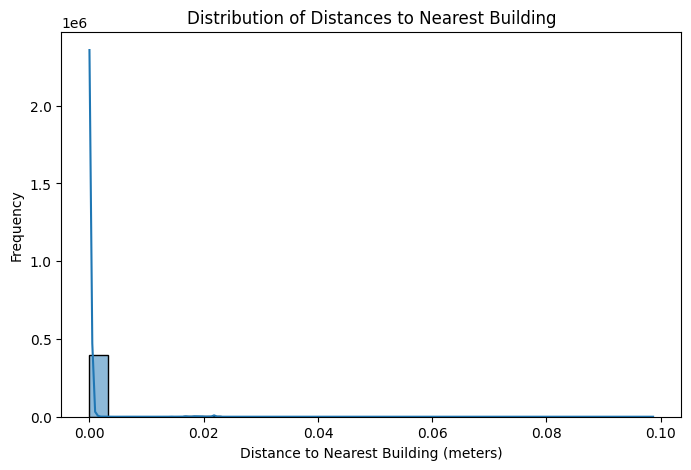

In [48]:
# Plot distance to nearest building
plt.figure(figsize=(8, 5))
sns.histplot(gps_with_buildings["building_distance"].dropna(), bins=30, kde=True)
plt.xlabel("Distance to Nearest Building (meters)")
plt.ylabel("Frequency")
plt.title("Distribution of Distances to Nearest Building")
plt.show()


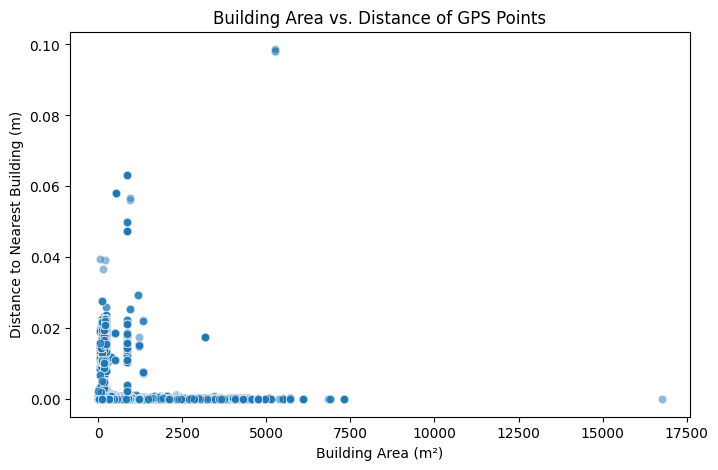

In [49]:
# Group by building area
plt.figure(figsize=(8, 5))
sns.scatterplot(data=gps_with_buildings, x="area_in_meters", y="building_distance", alpha=0.5)
plt.xlabel("Building Area (m²)")
plt.ylabel("Distance to Nearest Building (m)")
plt.title("Building Area vs. Distance of GPS Points")
plt.show()

